In [1]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup path
DATA_DIR = '../data/raw'
ZIP_PATH = os.path.join(DATA_DIR, 'ml-100k.zip')
EXTRACTED_DIR = os.path.join(DATA_DIR, 'ml-100k')

# Cek keberadaan file dan ekstrak jika belum diekstrak
if not os.path.exists(EXTRACTED_DIR):
    if os.path.exists(ZIP_PATH):
        print(f"File {ZIP_PATH} ditemukan. Memulai proses ekstraksi...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(DATA_DIR)
        print("Ekstraksi selesai! Data siap diproses.")
    else:
        print(f"ERROR: File tidak ditemukan. Tolong unduh manual dan letakkan di {DATA_DIR}")
else:
    print("Folder data ml-100k sudah ada. Data siap digunakan!")

Folder data ml-100k sudah ada. Data siap digunakan!


In [2]:
# Membaca data interaksi (user, item, rating, timestamp)
# File u.data menggunakan pemisah tab ('\t')
ratings_path = os.path.join(EXTRACTED_DIR, 'u.data')
df_interactions = pd.read_csv(ratings_path, sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])

print(f"Total baris data: {len(df_interactions)}")
display(df_interactions.head())

Total baris data: 100000


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


Total Unik User: 943
Total Unik Item: 1682
Sparsity (Kekosongan Data): 93.70%


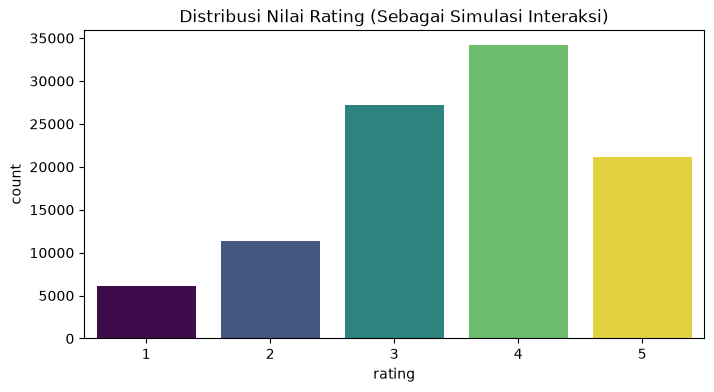

In [3]:
# Menghitung keunikan User dan Item
num_users = df_interactions['user_id'].nunique()
num_items = df_interactions['item_id'].nunique()
total_interactions = len(df_interactions)

# Menghitung Sparsity (Tingkat kekosongan matriks)
sparsity = 1 - (total_interactions / (num_users * num_items))

print(f"Total Unik User: {num_users}")
print(f"Total Unik Item: {num_items}")
print(f"Sparsity (Kekosongan Data): {sparsity * 100:.2f}%")

# Melihat distribusi "rating"
plt.figure(figsize=(8, 4))
sns.countplot(data=df_interactions, x='rating', hue='rating', palette='viridis', legend=False)
plt.title('Distribusi Nilai Rating (Sebagai Simulasi Interaksi)')
plt.show()